In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,646
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,646
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,646
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,736


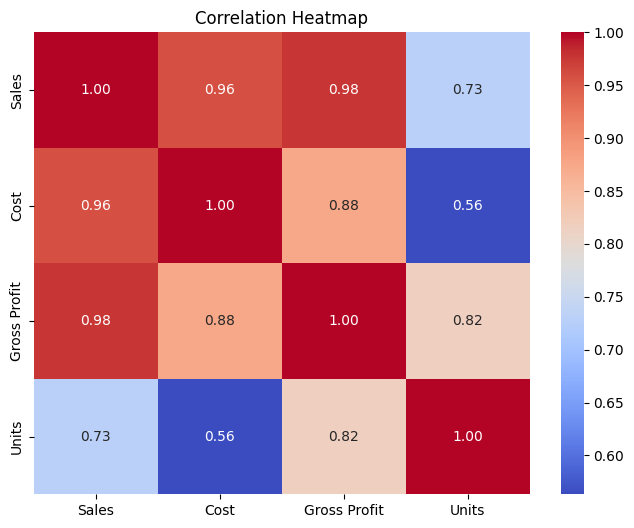

In [2]:
# Correlation Heatmap


plt.figure(figsize=(8,6))

corr = df[["Sales","Cost","Gross Profit","Units"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Sales and Gross Profit show a very strong positive correlation (~0.98), indicating that increased sales directly drive higher profitability.  
Units sold also correlate strongly with profit, suggesting that overall business performance is largely driven by sales volume.

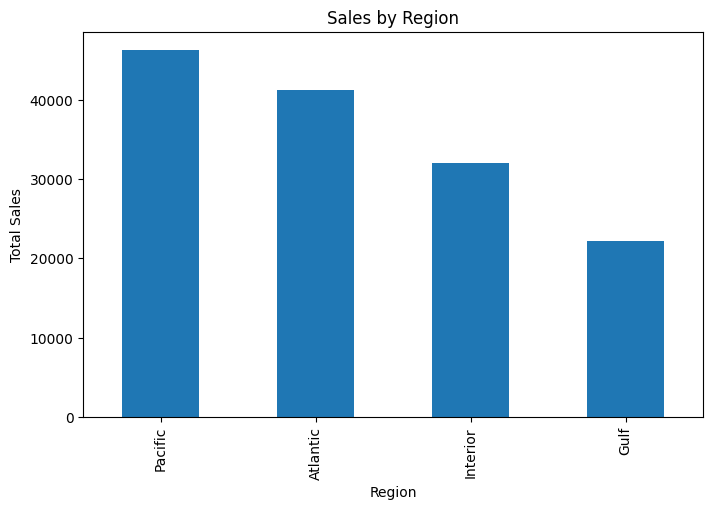

In [3]:
# Regional Sales Performance

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Total Sales")

plt.show()

 The Pacific region generates the highest total sales, followed by the Atlantic region.  
The Gulf region records the lowest sales, indicating potential opportunities for market expansion or improved distribution strategies in that region.

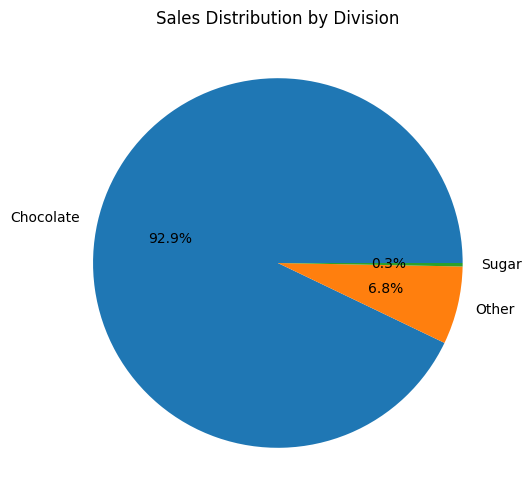

In [4]:
# Division Sales Performance

division_sales = df.groupby("Division")["Sales"].sum()

plt.figure(figsize=(6,6))

division_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Division")

plt.ylabel("")

plt.show()

The Chocolate division overwhelmingly dominates sales, contributing more than 90% of total revenue.  
This highlights a strong dependence on chocolate products, while Sugar and Other divisions contribute only a small share of sales.

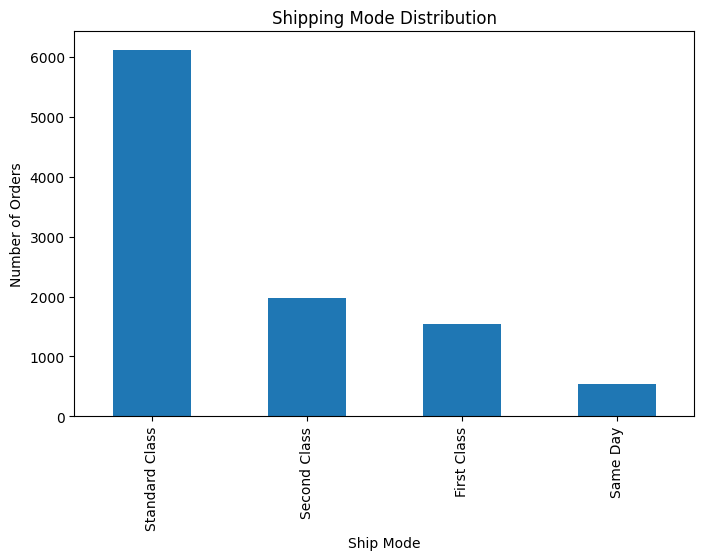

In [5]:
# Shipping Mode Analysis

ship_mode = df["Ship Mode"].value_counts()

plt.figure(figsize=(8,5))

ship_mode.plot(kind="bar")

plt.title("Shipping Mode Distribution")
plt.ylabel("Number of Orders")

plt.show()

Standard Class shipping accounts for the majority of orders, indicating a strong preference for cost-efficient delivery options.  
Faster shipping modes such as Same Day are used much less frequently, suggesting speed is not the primary priority for most orders.

In [6]:
df.to_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\final_dashboard_data.csv", index=False)